Polished notebook for EDA + training

## Data extraction

Functions to facilitate data extraction from specified path.

In [1]:
import pandas as pd
import numpy as np
import os
import functools

from functools import reduce

def read_fcnts_as_df(folder_path):
    """
    Extracts all feature count csvs from a specified folder and stores them as a list of dataframes

    Args:
        folder_path : File path containing Fcnts csv output from pipeline

    Returns: 
        fcnt_df_list : List of Fcnts dataframes
    """
    
    # Filter out the summary files and keep Fcnts from no-drug control (NDC) comparisons
    all_files = os.listdir(folder_path)
    files = [
        f for f in all_files
        if f.endswith(".csv")
        and ".summary" not in f
        and "NDC0hr" in f
            ]

    if len(files) == 0: 
        raise FileNotFoundError(f"No matching feature count files found in {folder_path}")

    # Convert each csv (which is stored as tab-delimited) to dataframe
    files = sorted(files)
    filenames = ["".join([folder_path, "/" , f]) for f in files]
    fcnt_df_list = [pd.read_table(f, sep = "\t", header = 0, skiprows = 1) for f in filenames]

    return fcnt_df_list

def sample_name_strip(name):
    """
    Convert a sample file name into an easy to read sample name
    Args:
        name : (ex: "/ExpOut/260107_AV242502_RNASeq_miniHT_SpnT4WT_CEF_CIP/Out/Rep/Bams/T4-wt12CEF12CIP1hr-a.bam")
        
    Returns:
        new_name : (ex: 12CEF12CIP1hr-a)
    """
    # Find index of the last / and remove entire prefix (OG file path)
    samplename_start_idx = name.strip().rfind("/") + 1
    new_name = name[samplename_start_idx:]

    # Find index of . (.bam is at end of sample name) and remove filetag
    filetag_start_idx = new_name.rfind(".")
    new_name = new_name[:filetag_start_idx]

    # Remove "T4-wt"
    new_name = new_name.replace("T4-wt", "")

    return new_name

def fcnts_to_tpms(fcnt_df_list):
    """
    Converts a list of RNA-seq feature count dataframes to a list of TPM dataframes

    Args:
        fcnt_df_list : List of feature count dataframes

    Returns:
        tpm_df_list : List of TPM dataframes

    """
    tpm_df_list = []

    for df in fcnt_df_list:

        # Move gene names to index and keep only length, Fcnts
        df = df.set_index("Geneid")
        df = df.loc[:, [col for col in list(df.columns) if col == "Length" or col.startswith("/")]]
        df = df.apply(lambda column: [int(entry) for entry in column])

        # Convert gene length from b -> kb
        df["Length"] = df["Length"].apply(lambda column: column / 1000)

        # Select Fcnts columns by excluding Length column
        fcnts_cols = [col for col in list(df.columns) if col != "Length"]
        
        # Fcnts / gene length = (Counts per kb)
        df[fcnts_cols] = df[fcnts_cols].apply(lambda column: column / df["Length"])

        # (Counts per kb) * 10^6 / (Total counts/kb) = TPM
        df[fcnts_cols] = df[fcnts_cols].apply(lambda column: column * 10**6 / sum(column))

        # Remove length column 
        df.drop(columns = "Length", inplace = True)
        
        # Apply stripper to each column names
        df = df.rename(columns = lambda column: sample_name_strip(column))
        tpm_df_list.append(df)        

    return tpm_df_list

def bind_tpm_data(tpm_df_list):
    """
    Function to take a list of TPM dataframes, then bind all into 1 dataframe
    Args: 
        tpm_df_list : list of TPM dataframes

    Returns:
        all_tpms [N,G] : dataframe with all TPM values (N samples on row, G genes on column)
    """
    tpm_df_list_uniq = []

    # Column names of 1st DF (all have last 3 cols)
    colnames = list(tpm_df_list[0].columns)

    # Select redundant NDC0hr columns and make new df with just those
    ndc0hr_cols = [col for col in colnames if "NDC0hr" in col]
    ndc0hr_df = tpm_df_list[0][ndc0hr_cols]
    tpm_df_list_uniq.append(ndc0hr_df)

    # Remove NDC0hr columns from all dfs
    for df in tpm_df_list:
        columns = list(df.columns)
        relevant_idx = [col for col in colnames if "NDC0hr" not in col]
        stripped_df = df[relevant_idx]
        tpm_df_list_uniq.append(stripped_df)

    all_tpms = reduce(lambda df1, df2 :
                      pd.merge(df1, df2, 
                               left_index = True, 
                               right_index = True, 
                               how = "outer"),
                      tpm_df_list_uniq)

    # Tranpose to get genes on columns
    all_tpms = all_tpms.T

    return all_tpms

def read_cfus(folder_path):
    """
    Function to extract CFUs into a dataframe with conditions on rows, 1 CFU column
    Args:
        folder_path : path to folder containing CFUs (same format as /all_cfus)

    Returns:
        all_cfus [N,1] : df with condition names as index, 1 column of CFUs (N = # samples)
    """

    # Get files
    files = os.listdir(folder_path)
    
    # Select CSV files
    cfu_files = [csv for csv in files if ".csv" in csv]
    cfu_files = sorted(cfu_files)
    cfu_files = ["".join([folder_path, "/", csv]) for csv in files]
    
    # Load each file as a dataframe
    cfu_dfs = [pd.read_table(csv, sep = ",", header = 0) for csv in cfu_files] 

    for i, df in enumerate(cfu_dfs):

        # Melt to get all triplicates stacked
        df = df.melt(id_vars = "Triplicates", var_name = "Condition", value_name = "CFU")

        # Define labels by combining condition + "-" + triplicate label
        df["Labels"] = df["Condition"].str.strip() + "-" + df["Triplicates"].str.strip()

        # Drop unncessary columns
        df = df.drop(columns = ["Condition", "Triplicates"])

        # Move labels to index
        df = df.set_index("Labels")
        cfu_dfs[i] = df
    
    # Concat
    all_cfus = pd.concat(cfu_dfs)

    return all_cfus

# Function to bind TPMs
def bind_all_data(tpm_df, cfu_df):
    """
    Function bind TPM and cfu dfs
    Args:
        tpm_df [N,G] : Dataframe of TPMs, N = # samples, G = # genes, labels on index
        cfu_df [N,1] : Dataframe of CFUs, labels on index

    Returns:
        data_df : [N, G+1] : Dataframe of all TPMs and CFUs as last column
    """
    # Right join so that CFUs exist
    data_df = pd.merge(tpm_df, cfu_df, left_index = True, right_index = True, how = "right")

    return data_df

def data_extract(fcnts_path, cfu_path):
    """
    Function to run entire data extraction pipeline

    Args:
        fcnts_path : Path to folder containing Fcnts output of lab pipeline
        cfu_path   : Path to folder containing CFU csv outputs

    Returns:
        all_data : [N, G+1] : Dataframe of all TPMs and CFUs as last column 
    """
    stored_fcnts = read_fcnts_as_df(fcnts_path)
    stored_tpms  = fcnts_to_tpms(stored_fcnts)
    tpm_df       = bind_tpm_data(stored_tpms)
    cfu_df       = read_cfus(cfu_path)
    all_data     = bind_all_data(tpm_df, cfu_df)
    
    return all_data

## Pre-processing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

We'll load our TPM/CFU data as a dataframe, then view.

In [2]:
# Load all data
all_data_pre = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_model_data.csv")

# Move condition column to index
all_data_pre.rename(columns = {"Unnamed: 0": "Condition"}, inplace = True)
all_data_pre = all_data_pre.set_index("Condition")
all_data_pre.head(n = 5)

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240,CFU
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX1hr-a,100.731718,62.523979,29.350576,136.628654,23.311941,18.360644,23.639356,54.915731,16.204642,49.999429,...,58.423669,5.190549,31.812428,12.352542,18.789319,0.000000,19.378051,1556.989150,2065.824961,1.380000e+09
12AMX1hr-b,110.761813,85.441234,30.011332,140.199108,12.290825,19.560271,10.495536,73.411867,11.391497,55.575063,...,49.943212,7.297677,28.384337,13.025337,23.951352,11.120270,13.622331,1560.789227,2192.495376,1.500000e+09
12AMX1hr-c,86.013352,62.605378,31.936738,128.435857,15.992967,18.401074,28.330836,63.601162,11.038218,47.381206,...,57.586997,5.050970,23.932111,11.333492,18.576600,24.629493,19.799804,1510.799073,1961.293782,1.440000e+09
12AMX2hr-a,58.112596,60.819299,42.382520,189.375150,24.848367,31.648666,49.926659,100.851174,27.094345,73.751491,...,50.583010,4.700939,18.412179,7.376283,13.194701,6.612310,21.985932,1074.685060,1070.619314,3.240000e+09
12AMX2hr-b,53.327570,56.106699,32.410598,193.525955,47.194380,29.561315,66.208488,138.513586,9.373100,74.497309,...,51.480457,5.504255,25.478260,10.717449,14.490841,0.000000,18.414236,1000.733037,996.438310,3.260000e+09


We'll check if any data has 0 CFU, which will mess our analysis up when we log-transform the CFUS.

In [ ]:
print(np.where(all_data_pre["CFU"] == 0))
print(all_data_pre.index[all_data_pre["CFU"] == 0].tolist())

(array([404]),)
['34CEF4hr-c']


Let's log-transform our CFU values, then remove the row with $-\infty$ CFU, which corresponds to the row we identified above. We can also check the range of CFU values to make sure it's reasonable for our modeling purposes.

In [5]:
# Log-transform CFUs
all_data_log = all_data_pre.copy()
all_data_log["CFU"] = np.log(all_data_log["CFU"])

# Filter out column with 0 CFU since log is -inf
all_data_log.replace([-np.inf], np.nan, inplace=True)
all_data_log.dropna(inplace = True)

# Checking the range of the log rmalized CFUs, this looks fine
print(f"Log CFU min : {all_data_log["CFU"].min()}")
print(f"Log CFU max : {all_data_log["CFU"].max()}")
print(f"Log CFU mean: {all_data_log["CFU"].mean()} \n")

# Check dimensions of data
print(f"# training examples : {all_data_log.shape[0]}")
print(f"# genes/features    : {all_data_log.shape[1]}")

Log CFU min : 12.89921982609012
Log CFU max : 24.323314077353732
Log CFU mean: 19.35072249856656 

# training examples : 470
# genes/features    : 2192


Let's also load our annotations so that we can use them later for interpretability.

In [6]:
# Read annotations
annotations = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/Annotation_TIGR4.tsv", sep = "\t")

# Set gene ID as index
annotations.set_index("TIGR4.old", inplace = True, drop = True)

# Dimensions
print(annotations.shape)
print(annotations.columns)
annotations.head(n = 5)

(1800, 30)
Index(['Cluster', 'Subcluster', 'Product', 'Strain', 'Genome', 'locus',
       'Start', 'End', 'Strand', 'Total.Insertions', 'Total.Sites', 'zbar',
       'Binomial.Call', 'HMM.Call', 'D39.old', 'TAIWAN.19F.new',
       'TAIWAN.19F.old', 'D39.new', 'GENE.DESCRIPTION', 'GENE.CATEGORY',
       'Location.Tag', 'Tag1', 'Tag2', 'Tag3', 'Category1', 'Category2',
       'Category3', 'No..of.Categories', 'Gene.Name',
       'GO.terms..biological.process.'],
      dtype='object')


,Cluster,Subcluster,Product,Strain,Genome,locus,Start,End,Strand,Total.Insertions,...,Location.Tag,Tag1,Tag2,Tag3,Category1,Category2,Category3,No..of.Categories,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,,,,,,,,,,
n.p.,1,1_5,DUF3278 domain-containing protein,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,1,1_2,endonuclease/exonuclease/phosphatase family pr...,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,Membrane,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
SP_0828,2,2_0,ribose-5-phosphate isomerase RpiA,TIGR4-AC316,CP035239,EQH41_04105,777989,778673,1,5,...,Intracellular,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,1.0,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,3,3_0,HU family DNA-binding protein,TIGR4-AC316,CP035239,EQH41_05540,1042358,1042634,1,0,...,Intracellular,GENETIC INFORMATION PROCESSING,NaN,NaN,Replication,NaN,NaN,1.0,NaN,chromosome condensation
SP_1925,4,4_0,hypothetical protein,TIGR4-AC316,CP035239,EQH41_09740,1826524,1827133,-1,16,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


Note that only 1800 out of 2192 genes are annotated. This is because we have some "in-between" fragments that were picked up in the RNA-seq experiment. Okay, we can subset our annotations to the stuff we actually care about.

In [7]:
# Gene data
annotations = annotations[["Product", "Tag1", "Tag2", "Tag3", "GENE.CATEGORY", "GENE.DESCRIPTION", "Location.Tag", "Category1", "Category2", "Category3", "Gene.Name", "GO.terms..biological.process."]]
annotations.head(n = 5)

,Product,Tag1,Tag2,Tag3,GENE.CATEGORY,GENE.DESCRIPTION,Location.Tag,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,
n.p.,DUF3278 domain-containing protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,endonuclease/exonuclease/phosphatase family pr...,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,Membrane,NaN,NaN,NaN,NaN,NaN
SP_0828,ribose-5-phosphate isomerase RpiA,METABOLISM,NaN,NaN,CARBOHYDRATE METABOLISM,ribose 5-phosphate isomerase,Intracellular,Carbohydrate metabolism,NaN,NaN,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,HU family DNA-binding protein,GENETIC INFORMATION PROCESSING,NaN,NaN,DNA TURNOVER,DNA-binding protein HU,Intracellular,Replication,NaN,NaN,NaN,chromosome condensation
SP_1925,hypothetical protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN


## Functions for training/evaluating models

### Train/test split

We need to group our conditions by triplicate, because we want each set of triplicates to end up together in either the train or test set. We can write a function to produce indices for us based on our input data. We'll assume that each triplicates has the same label, other than the last character, which can be "a", "b", or "c".

In [8]:
# Parameters : cond_list (list of condition labels, ex: "12CIP1hr-a", "12CIP1hr-b", etc)
# Output     : groups (list of labels according to condition, ex: 0, 0, 0, 1, 1, 1, etc.)
def groups_by_cond(cond_list):

    # Initialize list to store groups
    groups = [0]

    # Loop through conditions, beginning at second position
    for i in range(1, len(cond_list)):
        
        # Previous condition
        prev = cond_list[i-1]   
        curr = cond_list[i]

        # Matching label (apart from last letter)
        if prev[:-1] == curr[:-1]:
            groups.append(groups[i-1])
        
        # New label
        else:
            groups.append(groups[i-1] + 1)
    
    return groups

Next, let's define a function to do the following, given an X (predictors) and y (target):
1. Generate a list of groups for condition labels
2. Generate a splitter object
3. Obtain train and test indices for the train/test split
4. Generate train/test set

In [9]:
from sklearn.model_selection import GroupShuffleSplit 

# Parameters : X (predictors), y (target), train_size (0-1), group_func (group-making function)
# Output     : X_train, y_train, X_test, y_test

# Note: X must be a dataframe with index defined as condition name
#       y can be a dataframe or a series with index defined the same as X

def group_ttsplit(X, y, train_size, group_func):

    # Make splitter
    gss = GroupShuffleSplit(n_splits = 1, train_size = train_size, random_state = 111)

    # Define groups
    groups = group_func(X.index)

    # Obtain indices for train and test split
    train_idx, test_idx = next(gss.split(X, groups = groups))

    # Define train, test sets
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]

    return X_train, y_train, X_test, y_test

Next, a function to take the sample names and convert them to drug name

In [11]:
def drug_reader(x):

    # Single drug
    if len(x) < 11:
        
        # If NDC
        if x[:3] == "NDC":
            return "NDC"
        
        # If another drug
        else:
            
            # Construct of array of 1s and 0s depending on if character
            binary = np.array([int(char.isalpha()) for char in x])

            # Find first 1, then grap drug name
            first_char = np.where(binary == 1)[0][0]
            return x[first_char:first_char+3]
    
    # Multiple drug
    else:

        # Extract drug
        drug_name =  x[2:5] + "+" + x[7:10]
        return drug_name

Now, we'll write a function that generates a PrettyTable for us including all of the metrics that we want (R^2 train, R^2 test, MSE, MAE)

In [12]:
from sklearn import ensemble
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn import preprocessing

import prettytable
from prettytable import PrettyTable

# Parameters : title, model_list (list of trained models), name_list (list of model names), data (X_train, y_train, X_test, y_test)
# Output     : Table with each model including R^2 train, R^2 test, MSE, MAE

def eval_table(title, model_list, name_list, data):

    # Initialize table for eval metrics
    table = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

    # Load data
    X_train_, y_train_ = data[0], data[1]
    X_test_, y_test_   = data[2], data[3]

    # Add model eval metrics to table
    for i in range(len(model_list)):

        # Compute predictions
        preds = model_list[i].predict(X_test_)

        # Add eval metrics
        table.add_row([name_list[i],
                       round(root_mean_squared_error(y_test_, preds), 4),
                       round(mean_absolute_error(y_test_, preds), 4),
                       round(model_list[i].score(X_train_, y_train_), 4),
                       round(model_list[i].score(X_test_, y_test_), 4)])
    
    # Title
    table.title = title

    return table

This function will take a regression model, then output the features sorted in decreasing order by their coefficients, along with annotations.

In [13]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_reg(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.coef_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

We can define the same for a random forest model.

In [14]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_tree(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.feature_importances_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

Next, we'll define a function to plot the top $n$ features based on the magnitude of their coefficients.

In [15]:
# Parameteres : coefs (df of coefs ordered by magnitude, with index), n (# coefs to see), 
#               annotations (for features), title
# Output      : plot

def plot_coefs(coefs, n, annots, title):

    # Merge coefficients with annotations
    annotated = pd.merge(coefs, annots, how = "left", left_index = True, right_index = True)

    # Subplots
    fig, ax = plt.subplots()

    # Barplot of coefficients
    annotated.iloc[:n].plot(kind = "barh", ax = ax).invert_yaxis()

    # Plot
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Gene")
    ax.axvline(x = 0, color = ".5")

    # Secondary axis for gene IDs
    secax = ax.secondary_yaxis("left")
    secax.set_yticks(range(len(annotated.iloc[:30].index)))
    secax.set_yticklabels(annotated.iloc[:30]["Product"])
    secax.spines['left'].set_position(('outward', 130))
    secax.set_ylabel("Gene product")

## Train on all standard-scaled features

Train/test split on all the original data.

In [16]:
from sklearn.model_selection import StratifiedGroupKFold

# Load all data
X_all = all_data_log.iloc[:, all_data_log.columns != "CFU"]
y_all = all_data_log.iloc[:, all_data_log.columns == "CFU"]

# Splitter object
splitter = StratifiedGroupKFold(
    n_splits = 4,        # 75/25 train test split
    shuffle = True,      
    random_state = 112)

# Generate class labels
drug_classes = np.array([drug_reader(name) for name in list(X_all.index)])

# Generate triplicate labels
rep_labels = np.array(groups_by_cond(list(X_all.index)))

# Generate indices (take first of 4 folds)
train_idx, test_idx = next(splitter.split(X_all, drug_classes, rep_labels))

# Split
X_all_train, y_all_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
X_all_test, y_all_test   = X_all.iloc[test_idx], y_all.iloc[test_idx]

# Store data sizes
data_size  = X_all.shape[0]
train_size = X_all_train.shape[0]
test_size  = X_all_test.shape[0]
# Size
print(f"Size of data         : {data_size}")
print(f"Size of training set : {train_size} ({round(train_size*100/ data_size, 1)} %)")
print(f"Size of test set     : {test_size} ({round(test_size*100/ data_size, 1)} %)")

Size of data         : 470
Size of training set : 350 (74.5 %)
Size of test set     : 120 (25.5 %)


This time, we'll try applying a standardscaler to all of our features. This will subtract all features by the the correpsonding mean and scale by the std.

In [17]:
from sklearn.preprocessing import StandardScaler

# Scalers for train and test data (separate so we don't have to resplit)
scaler1 = StandardScaler()

# Set output to preserve df
scaler1.set_output(transform = "pandas")

# Fit scalers
scaler1.fit(X_all_train)

# Transform data
X_scaled_train = scaler1.transform(X_all_train)
X_scaled_test  = scaler1.transform(X_all_test)

X_scaled_test

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2230,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240
Condition,,,,,,,,,,,,,,,,,,,,,
12CEF12CIP2hr-a,-0.456600,-0.812278,0.177298,-0.105693,-0.006087,-0.582611,-0.951581,-0.598385,-0.237799,-0.456802,...,0.388168,-0.000070,-0.561779,-0.186597,-0.342923,-0.241525,-0.490516,0.201324,0.588563,0.342391
12CEF12CIP2hr-b,-0.195364,-0.741859,0.057388,-0.060240,-0.514929,-0.635692,-0.364740,-0.532857,-1.129896,-0.486316,...,0.438831,0.060894,-0.854084,0.032148,0.176764,-0.301008,-0.343732,-0.341418,0.625126,0.436629
12CEF12CIP2hr-c,-0.486644,-0.569513,-0.314756,-0.197036,-0.423330,-0.403148,-0.154891,-0.785829,-0.433582,-0.555304,...,0.336475,-0.015067,-0.651528,0.077544,-0.391292,-0.222019,0.047473,-0.038985,0.594115,0.385028
12CEF13CIP2hr-a,-0.650255,-0.614541,-0.648458,-0.434815,-0.732257,-0.871402,-1.042340,-0.761265,-0.947980,-0.834662,...,-0.136689,-0.478036,-0.362614,-0.312602,-0.622035,-0.085756,0.347600,-0.235006,0.426235,0.216324
12CEF13CIP2hr-b,-0.819293,-0.896727,-0.764920,-0.460152,-0.225320,-0.705349,-1.364370,-0.637646,-1.156172,-0.825062,...,-0.273578,-0.231476,-0.592210,-0.898893,-0.219638,-0.492096,-0.761803,-1.013835,0.237857,0.190472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34CIP34VNC2hr-b,0.515167,0.305119,0.401749,0.467431,0.509242,0.231150,-0.554493,0.027045,0.835900,0.120251,...,0.340699,0.630104,0.419310,0.420409,0.786343,0.259199,0.287793,0.366730,0.637474,0.254832
34CIP34VNC2hr-c,0.305346,0.423006,0.027058,0.726824,0.634952,0.087880,0.295990,0.363871,0.108155,0.017149,...,0.595405,0.331450,0.210023,0.934071,0.027697,0.537608,-0.626581,-0.430791,0.630477,0.303810
NDC4hr-a,-1.466776,-1.126719,-0.856456,-1.103003,-0.965989,-0.497705,-0.429954,-0.441099,-0.096147,-0.531707,...,-1.072507,-1.129133,-0.723136,-0.588032,-0.677024,-0.797301,-0.413614,0.359540,-0.345425,-0.385128


Initialize 7 different regression models.

In [115]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Models
scaled_lm    = linear_model.LinearRegression()
scaled_lasso = linear_model.LassoCV(cv = 5)
scaled_ridge = linear_model.RidgeCV(cv = 5)
scaled_en    = linear_model.ElasticNetCV(cv = 5)
scaled_lars  = linear_model.LarsCV(cv = 5)
scaled_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)
scaled_xgb   = xgb.XGBRegressor(objective='reg:squarederror', n_estimators = 100, random_state = 111)


Perform gridsearch for XGBoost hyperparmater tuning.

In [ ]:
# # Hyperparameter tuning for XGboost
# xgb_param_grid = {
#     "eta": [0.05, 0.1, 0.2],
#     "subsample": [0.5, 0.75, 1.0],
#     "colsample_bytree": [0.5, 0.75, 1.0],
#     "alpha": np.arange(0, 1, 0.1)
# }

# # XGBoost grid search
# xgb_grid_search  = GridSearchCV(
#     estimator = scaled_xgb, 
#     param_grid=xgb_param_grid, 
#     cv=3, n_jobs=-1, verbose=1)
# xgb_grid_search.fit(X_scaled_train, y_all_train)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


In [ ]:
# # Hyperparameter tuning for RF model


# # EDIT FOR RANDOM FOREST
# # rf_param_grid = {
#     "eta": [0.05, 0.1, 0.2],
#     "max_depth": [3, 6, 9],
#     "subsample": [0.5, 0.75, 1.0],
#     "colsample_bytree": [0.5, 0.75, 1.0],
#     "alpha": np.arange(0.1, 15, 0.2)
# }


# # # XGBoost grid search
# rf_grid_search  = GridSearchCV(
#     estimator = scaled_rf, 
#     param_grid=rf_param_grid, 
#     cv=5, n_jobs=-1, verbose=1)
# rf_grid_search.fit(X_scaled_train, y_all_train)

# rf_grid_search.best_params_
# # Tune

In [116]:
# Fit
scaled_lm.fit(X_scaled_train, y_all_train)
scaled_lasso.fit(X_scaled_train, y_all_train)
scaled_ridge.fit(X_scaled_train, y_all_train)
scaled_en.fit(X_scaled_train, y_all_train)
scaled_rf.fit(X_scaled_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.056e-01, tolerance: 9.771e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklea

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Look at the regularization hyperparameters:

In [125]:
print(f"LASSO alpha      : {scaled_lasso.alpha_}")
print(f"Ridge alpha      : {scaled_ridge.alpha_}")
print(f"ElasticNet alpha : {scaled_en.alpha_}")

LASSO alpha      : 0.043855029465098484
Ridge alpha      : 10.0
ElasticNet alpha : 0.07628573627408583


Evaluate.

In [117]:
print(eval_table(title = "Models with all standard-scaled features",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train, y_all_train, X_scaled_test, y_all_test]))

+------------------------------------------------------------+
|          Models with all standard-scaled features          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 1.0155 | 0.5868 |     1.0     |   0.7907   |
|     LASSO     | 0.8999 | 0.602  |    0.9215   |   0.8357   |
|     Ridge     | 0.9919 | 0.5796 |    0.9998   |   0.8004   |
|   ElasticNet  | 0.8628 | 0.5923 |    0.9282   |   0.849    |
| Random Forest | 0.8753 | 0.5862 |    0.979    |   0.8445   |
+---------------+--------+--------+-------------+------------+


We're also interested in finding the performance metrics of the model only on certain data types. Let's try subsetting our data based on the condition name, so that we can see the R^2 on different drugs! 

In [119]:
# Indices of each datatype in the train/test sets

# CIP
cip_index_train = [i for i in range(X_scaled_train.shape[0]) if "CIP" in X_scaled_train.iloc[i].name and
                   "CEF" not in X_scaled_train.iloc[i].name and 
                   "VNC" not in X_scaled_train.iloc[i].name]
cip_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CIP" in X_scaled_test.iloc[i].name and
                   "CEF" not in X_scaled_test.iloc[i].name and 
                   "VNC" not in X_scaled_test.iloc[i].name]

# CEF
cef_index_train = [i for i in range(X_scaled_train.shape[0]) if "CEF" in X_scaled_train.iloc[i].name
                   and "CIP" not in X_scaled_train.iloc[i].name]
cef_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CEF" in X_scaled_test.iloc[i].name
                   and "CIP" not in X_scaled_test.iloc[i].name]

# AMX
amx_index_train = [i for i in range(X_scaled_train.shape[0]) if "AMX" in X_scaled_train.iloc[i].name]
amx_index_test  = [i for i in range(X_scaled_test.shape[0]) if "AMX" in X_scaled_test.iloc[i].name]

# VNC
vnc_index_train = [i for i in range(X_scaled_train.shape[0]) if "VNC" in X_scaled_train.iloc[i].name
                   and "CIP" not in X_scaled_train.iloc[i].name]
vnc_index_test  = [i for i in range(X_scaled_test.shape[0]) if "VNC" in X_scaled_test.iloc[i].name
                   and "CIP" not in X_scaled_test.iloc[i].name]

Let's do the same for single vs. multiple drug data

In [120]:
# Single drug (check that there are 3 capital letters in the name)
single_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 3]
single_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 3]

# Combination drug (check that there are 6 capital letters in the name)
combo_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 6]
combo_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 6]


Now we can make eval tables for each datatype!

In [121]:
tbl1 = eval_table(title = "Model performance on CIP data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cip_index_train], y_all_train.iloc[cip_index_train], X_scaled_test.iloc[cip_index_test], y_all_test.iloc[cip_index_test]])
tbl2 = eval_table(title = "Model performance on CEF data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cef_index_train], y_all_train.iloc[cef_index_train], X_scaled_test.iloc[cef_index_test], y_all_test.iloc[cef_index_test]])
tbl3 = eval_table(title = "Model performance on AMX data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[amx_index_train], y_all_train.iloc[amx_index_train], X_scaled_test.iloc[amx_index_test], y_all_test.iloc[amx_index_test]])
tbl4 = eval_table(title = "Model performance on VNC data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[vnc_index_train], y_all_train.iloc[vnc_index_train], X_scaled_test.iloc[vnc_index_test], y_all_test.iloc[vnc_index_test]])
tbl5 = eval_table(title = "Model performance on single-drug data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[single_index_train], y_all_train.iloc[single_index_train], X_scaled_test.iloc[single_index_test], y_all_test.iloc[single_index_test]])
tbl6 = eval_table(title = "Model performance on combination data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[combo_index_train], y_all_train.iloc[combo_index_train], X_scaled_test.iloc[combo_index_test], y_all_test.iloc[combo_index_test]])

Let's plot the R^2 (train) of each model for each data type. The R^2(test) are all essentially the same.

In [122]:
# Store r^2
r2s = [row[4] for row in tbl1.rows] + [row[4] for row in tbl2.rows] + [row[4] for row in tbl3.rows] + [row[4] for row in tbl4.rows] + [row[4] for row in tbl5.rows] + [row[4] for row in tbl6.rows]

datatypes = ["CIP"]*5 + ["CEF"]*5 + ["AMX"]*5 + ["VNC"]*5 + ["Single-drug"]*5 + ["Multi-drug"]*5

# Construct dataframe of R^2 (train) for each model
evals = {
    "Model": ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"]*6,
    "Datatype": datatypes,
    "R^2 (test)": r2s
}

# DF
evals = pd.DataFrame(evals)

Text(0.5, 1.0, 'Models trained using standard-scaled features')

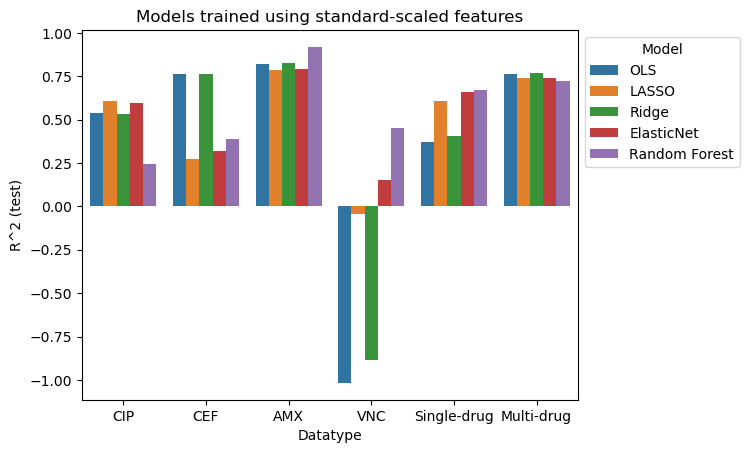

In [123]:
ax = sns.barplot(data = evals, x = "Datatype", y = "R^2 (test)", hue = "Model")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title("Models trained using standard-scaled features")

Let's visualize as scatter plots. First create a dataframe consisting of the test data CFUs, then bind all the predicted values.

In [126]:
# Get true CFUs
eval_df = pd.DataFrame(y_all_test)

# Get predicted CFUs
eval_df["OLS preds"] = scaled_lm.predict(X_scaled_test)
eval_df["LASSO preds"] = scaled_lasso.predict(X_scaled_test)
eval_df["Ridge preds"] = scaled_ridge.predict(X_scaled_test)
eval_df["EN preds"] = scaled_en.predict(X_scaled_test)
eval_df["RF preds"] = scaled_rf.predict(X_scaled_test)
eval_df["Time"] = eval_df.index

# Convert ln CFUs to log10 CFUs
cols = ["CFU", "OLS preds", "LASSO preds", "Ridge preds", "EN preds", "RF preds"]
eval_df[cols] = eval_df[cols].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df["Time"] = eval_df["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df["Drug"] = eval_df.index


eval_df["Drug"] = eval_df["Drug"].apply(drug_reader)

In [127]:
eval_df

,CFU,OLS preds,LASSO preds,Ridge preds,EN preds,RF preds,Time,Drug
Condition,,,,,,,,
12CEF12CIP2hr-a,7.763428,7.888673,7.780695,7.887118,7.766818,7.881648,2hr,CEF+CIP
12CEF12CIP2hr-b,7.892095,7.807045,7.860464,7.821254,7.876418,7.884835,2hr,CEF+CIP
12CEF12CIP2hr-c,8.049218,7.879026,7.710684,7.868657,7.723375,7.936569,2hr,CEF+CIP
12CEF13CIP2hr-a,7.963788,7.999908,7.601019,7.983389,7.625706,7.505271,2hr,CEF+CIP
12CEF13CIP2hr-b,8.100371,8.034478,7.859196,8.020484,7.854929,7.631707,2hr,CEF+CIP
...,...,...,...,...,...,...,...,...
34CIP34VNC2hr-b,7.832509,8.032548,8.059969,8.035672,8.102242,8.325202,2hr,CIP+VNC
34CIP34VNC2hr-c,7.662758,7.873752,8.051697,7.886834,8.076730,8.256253,2hr,CIP+VNC
NDC4hr-a,10.326336,9.882662,9.924022,9.889049,9.929437,9.475366,4hr,NDC


([<matplotlib.axis.YTick at 0x1f68c8f7d90>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

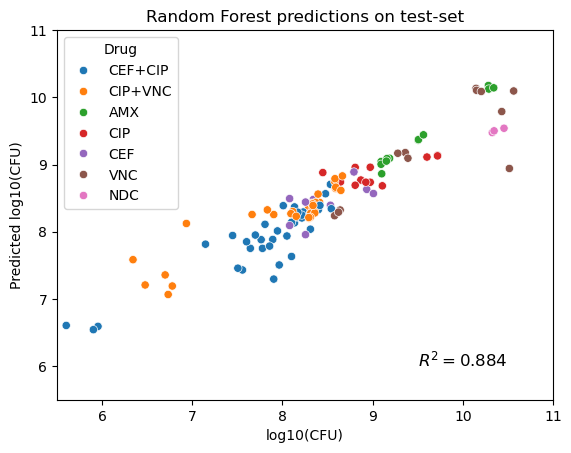

In [134]:
# Set drug order
ordered_drugs = ["CEF+CIP","CIP+VNC", "AMX", "CIP", "CEF", "VNC", "NDC"]

sns.scatterplot(eval_df, x = "CFU", y = "RF preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("Random Forest predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8845:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x1f68c652850>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

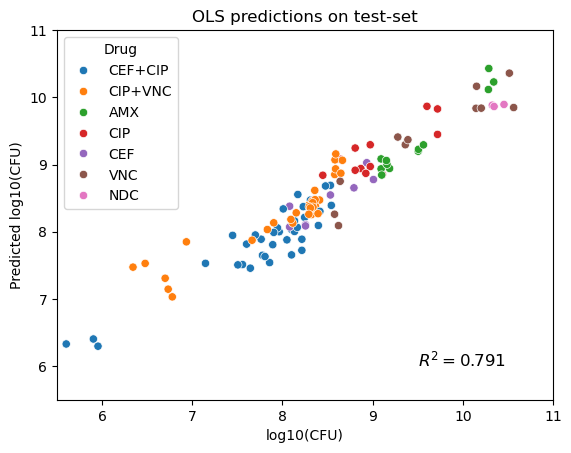

In [135]:
sns.scatterplot(eval_df, x = "CFU", y = "OLS preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("OLS predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.7907:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x1f68dae9810>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

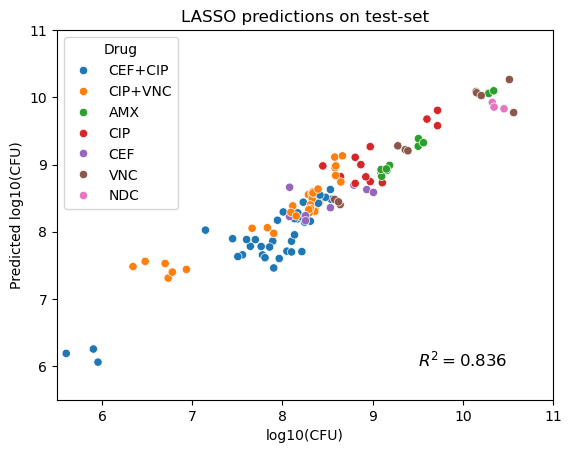

In [136]:
sns.scatterplot(eval_df, x = "CFU", y = "LASSO preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("LASSO predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8357:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x1f68db17110>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

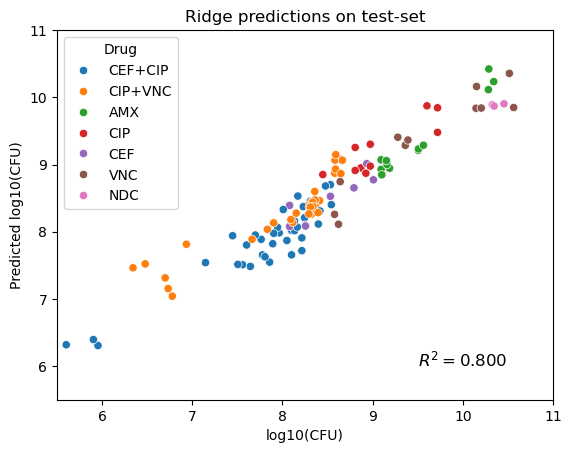

In [137]:
sns.scatterplot(eval_df, x = "CFU", y = "Ridge preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("Ridge predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8004:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

([<matplotlib.axis.YTick at 0x1f68c75dd10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

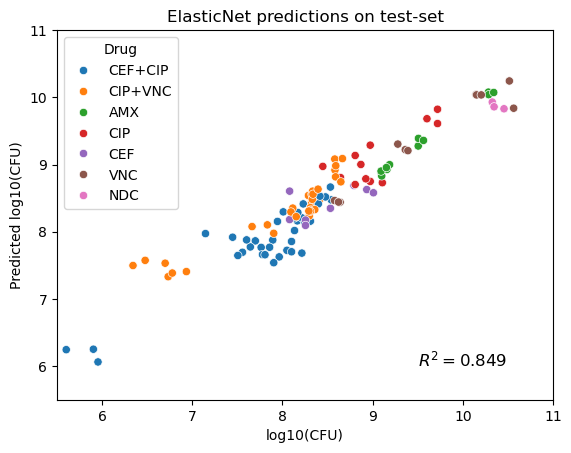

In [138]:
sns.scatterplot(eval_df, x = "CFU", y = "EN preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions on test-set")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.849:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

Stable performance across classes

Coefficient extraction:

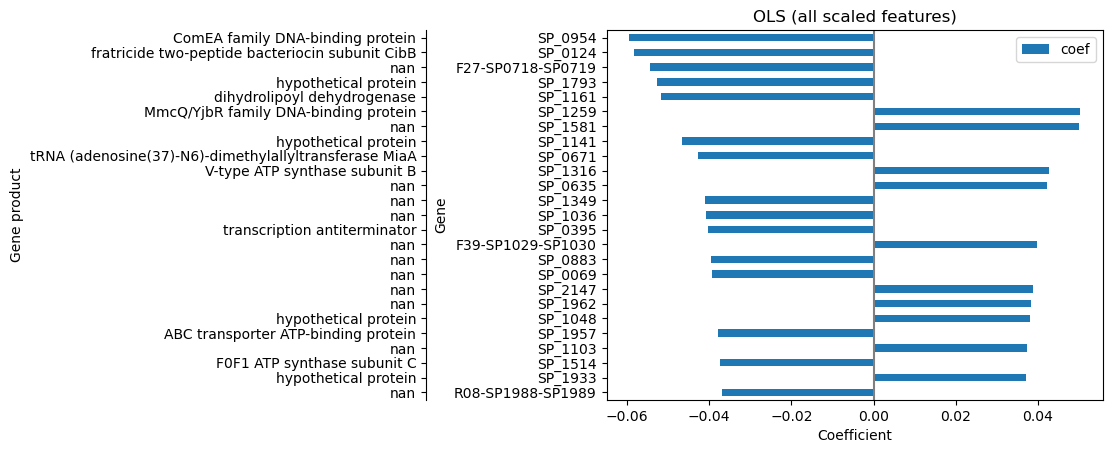

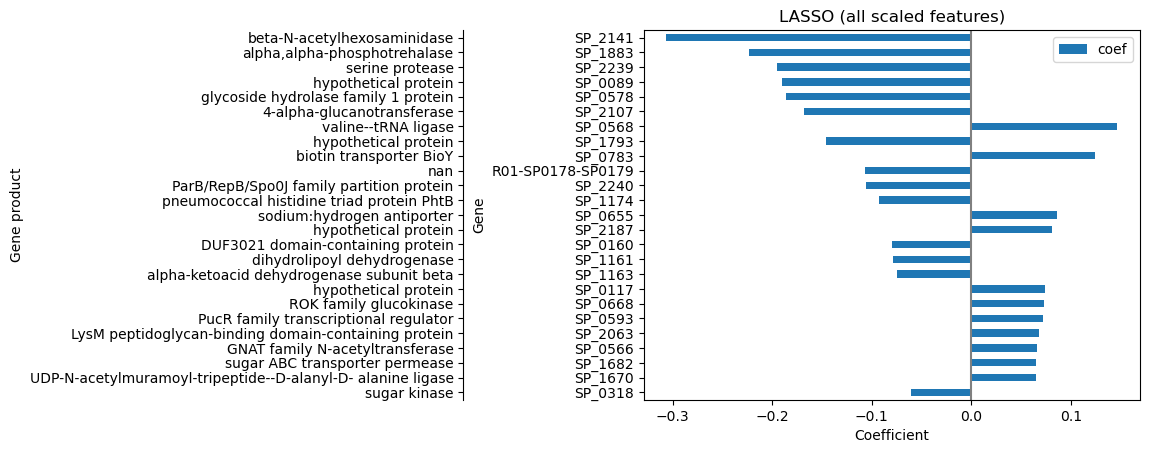

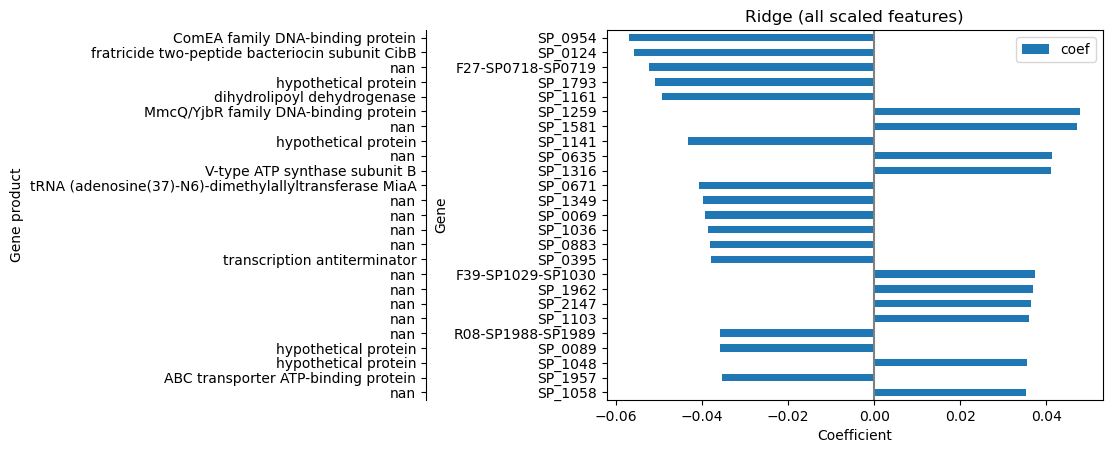

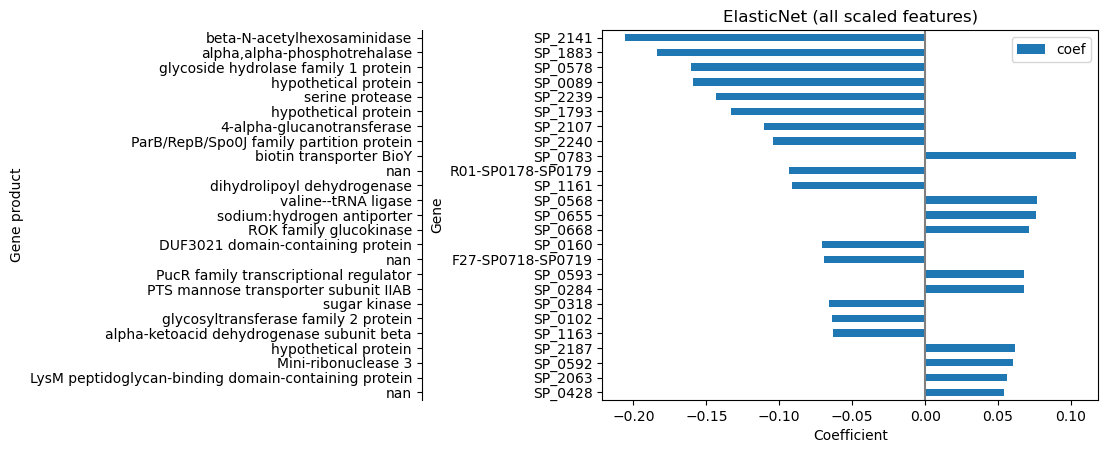

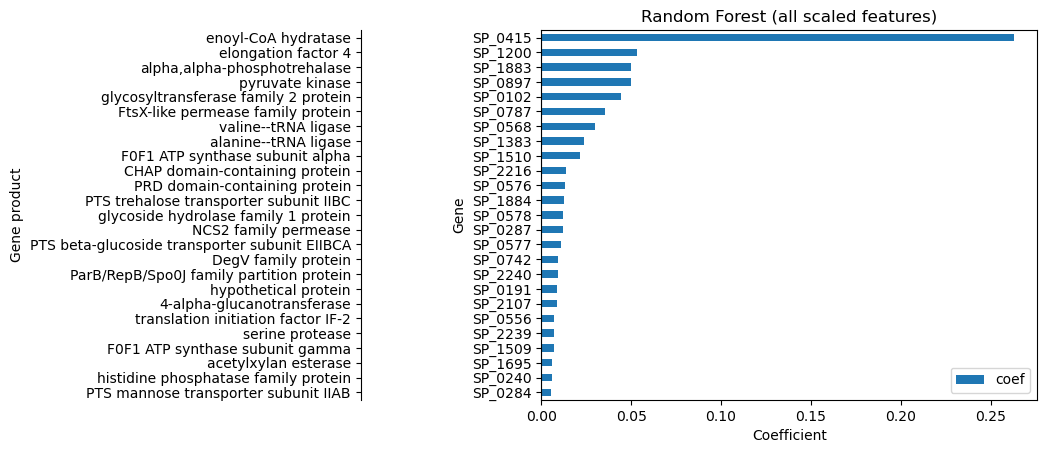

In [139]:
plot_coefs(feature_sort_reg(scaled_lm, X_scaled_train), 25, annotations, "OLS (all scaled features)")
plot_coefs(feature_sort_reg(scaled_lasso, X_scaled_train), 25, annotations, "LASSO (all scaled features)")
plot_coefs(feature_sort_reg(scaled_ridge, X_scaled_train), 25, annotations, "Ridge (all scaled features)")
plot_coefs(feature_sort_reg(scaled_en, X_scaled_train), 25, annotations, "ElasticNet (all scaled features)")
plot_coefs(feature_sort_tree(scaled_rf, X_scaled_train), 25, annotations, "Random Forest (all scaled features)")

## Repeat above but with cross-validation

Try LARS regression and XGboost as well for regression! (gridsearchCV). Will train models with cross-validatiaon in order to get generali performance on data.

In [86]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import cross_val_score

# Splitter object
sgkf = StratifiedGroupKFold(
    n_splits = 4,        # 75/25 train test split
    shuffle = True,      # Flase or True??
    random_state = 111)

# Generate class labels
drug_classes = np.array([drug_reader(name) for name in list(X_all.index)])

# Generate triplicate labels
rep_labels = np.array(groups_by_cond(list(X_all.index)))

# Generate indices 
sgkf.split(X_all, drug_classes, rep_labels)
# Look back at the function group_ttsplitter function later*
for i, (train_index, test_index) in enumerate(sgkf.split(X_all, drug_classes, rep_labels)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"         group={rep_labels[train_index]}")
    print(f"  Test:  index={test_index}")
    print(f"         group={rep_labels[test_index]}")

Fold 0:
  Train: index=[  0   1   2   3   4   5   9  10  11  12  13  14  21  22  23  24  25  26
  27  28  29  30  31  32  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 114 115 116 123 124 125 126 127 128 129 130 131 132 133 134
 135 136 137 138 139 140 141 142 143 147 148 149 153 154 155 159 160 161
 165 166 167 168 169 170 174 175 176 180 181 182 183 184 185 186 187 188
 189 190 191 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 231 232 233 234 235 236 240 241 242 243 244 245 246 247 248 249 250 251
 252 253 254 255 256 257 258 259 260 264 265 266 267 268 269 270 271 272
 273 274 275 276 277 278 279 280 281 285 286 287 288 289 290 291 292 293
 294 295 296 297 298 299 300

Now, let's iteratively train each of our models on each generated split.

In [92]:
# Implementing models
lm_cv    = linear_model.LinearRegression()
lasso_cv = linear_model.LassoCV(cv = 5)
ridge_cv = linear_model.RidgeCV(cv = 5)
en_cv    = linear_model.ElasticNetCV(cv = 5)
rf_cv    = ensemble.RandomForestRegressor(n_estimators = 100)

# Store models
model_list = [lm_cv, lasso_cv, ridge_cv, en_cv, rf_cv]

# Initialize lists to store R^2 for each model
lm_scores    = []
lasso_scores = []
ridge_scores = []
en_scores    = []
rf_scores    = []

# Store score lists
score_lists = [lm_scores, lasso_scores, ridge_scores, en_scores, rf_scores]

# For model in lm_scores

# For each model
for i in range(len(score_lists)):

    # Iterate through each fold
    for train_index, test_index in sgkf.split(X_all, drug_classes, rep_labels):

        # Define train/test sets
        x_train_fold, x_test_fold = X_all.iloc[train_index], X_all.iloc[test_index]
        y_train_fold, y_test_fold = y_all.iloc[train_index], y_all.iloc[test_index]

        # StandardScaler
        scaler = StandardScaler()
        scaler.set_output(transform="pandas")

        # Fit scaler
        scaler.fit(x_train_fold)

        # Transform data
        x_train_fold = scaler.transform(x_train_fold)
        x_test_fold = scaler.transform(x_test_fold)

        # Fit model
        model_list[i].fit(x_train_fold, y_train_fold)

        # Append score
        score_lists[i].append(model_list[i].score(x_test_fold, y_test_fold))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.223e-01, tolerance: 8.990e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklea

Now, we evaluate the mean score and std of the score

In [98]:
# Generate a table to output results
cv_table = PrettyTable(["Model", "Mean R^2", "Std R^2"])

# Generate Model names
model_name_list = ["OLS","Lasso", "Ridge", "ElasticNet", "Random Forest"]

for i in range(len(score_lists)):
    cv_table.add_row([model_name_list[i],
                      round(np.mean(score_lists[i]), 4),
                      round(np.std(score_lists[i]), 4)
                      ]
                     )

# Set title
cv_table.title = "R^2 for 4-fold cross-validated models" 
print(cv_table)



+---------------------------------------+
| R^2 for 4-fold cross-validated models |
+----------------+----------+-----------+
|     Model      | Mean R^2 |  Std R^2  |
+----------------+----------+-----------+
|      OLS       |  0.7538  |   0.0567  |
|     Lasso      |  0.766   |   0.063   |
|     Ridge      |  0.7598  |   0.0542  |
|   ElasticNet   |  0.7751  |   0.053   |
| Random Forest  |  0.7789  |   0.0234  |
+----------------+----------+-----------+


## Train models for hold-out concentration and timepoint

### 0.25x MIC held out

In [57]:
# Select indicies corresponding to if 1/4 MIC data
idx14_y = [i for i in range(X_all.shape[0]) if "14" in X_all.index[i]]
idx14_n = [i for i in range(X_all.shape[0]) if "14" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_14, y_train_14 = X_all.iloc[idx14_n], y_all.iloc[idx14_n]
X_test_14, y_test_14   = X_all.iloc[idx14_y], y_all.iloc[idx14_y]

# Fit scaler and transform data
scaler14 = StandardScaler()
scaler14.set_output(transform = "pandas")
scaler14.fit(X_train_14)
X_train_14 = scaler14.transform(X_train_14)
X_test_14  = scaler14.transform(X_test_14)

# Train EN model
en14 = linear_model.ElasticNetCV(cv = 5)

en14.fit(X_train_14, y_train_14)

print(eval_table(title = "0.25x MIC held out",
           model_list = [en14],
           name_list = ["ElasticNet"],
           data = [X_train_14, y_train_14, X_test_14, y_test_14]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.25x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.7311 | 0.4565 |    0.947    |   0.759    |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1f681d38690>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

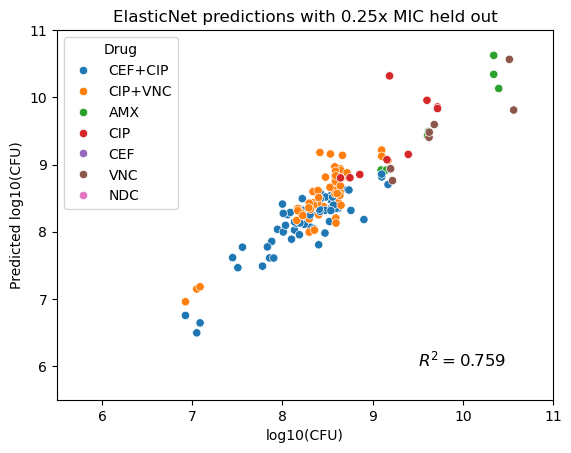

In [ ]:
# Scatterplot of predictions
eval_df14 = pd.DataFrame(y_test_14)

# Get predicted CFUs
eval_df14["Preds"] = en14.predict(X_test_14)

# Log 10 conversion
eval_df14[["CFU", "Preds"]] = eval_df14[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df14["Time"] = eval_df14.index
eval_df14["Time"] = eval_df14["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df14["Drug"] = eval_df14.index

# Drug names
eval_df14["Drug"] = eval_df14["Drug"].apply(drug_reader)

# Sort alphabetically by index
eval_df14 = eval_df14.sort_index()

sns.scatterplot(eval_df14, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.25x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.759:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

### 0.33x MIC held out

In [ ]:
# Select indicies corresponding to if 1/4 MIC data
idx13_y = [i for i in range(X_all.shape[0]) if "13" in X_all.index[i]]
idx13_n = [i for i in range(X_all.shape[0]) if "13" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_13, y_train_13 = X_all.iloc[idx13_n], y_all.iloc[idx13_n]
X_test_13, y_test_13   = X_all.iloc[idx13_y], y_all.iloc[idx13_y]

# 
scaler13 = StandardScaler()
scaler13.set_output(transform = "pandas")

# Fit scaler and transform data
scaler13.fit(X_train_13)
X_train_13 = scaler13.transform(X_train_13)
X_test_13  = scaler13.transform(X_test_13)

# Train EN model
en13 = linear_model.ElasticNetCV(cv = 5)

en13.fit(X_train_13, y_train_13)

print(eval_table(title = "0.33x MIC held out",
           model_list = [en13],
           name_list = ["ElasticNet"],
           data = [X_train_13, y_train_13, X_test_13, y_test_13]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.33x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.5777 | 0.4399 |    0.9767   |   0.8609   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1ac71c21e50>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

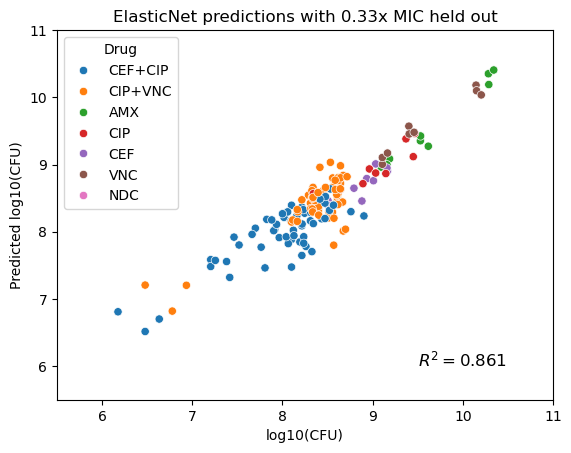

In [ ]:
# Scatterplot of predictions
eval_df13 = pd.DataFrame(y_test_13)

# Get predicted CFUs
eval_df13["Preds"] = en13.predict(X_test_13)

# Log 10 conversion
eval_df13[["CFU", "Preds"]] = eval_df13[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df13["Time"] = eval_df13.index
eval_df13["Time"] = eval_df13["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df13["Drug"] = eval_df13.index

# Drug names
eval_df13["Drug"] = eval_df13["Drug"].apply(drug_reader)

sns.scatterplot(eval_df13, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.33x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8609:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))

### 0.5x MIC held out

In [ ]:
# Select indicies corresponding to if 1/4 MIC data
idx12_y = [i for i in range(X_all.shape[0]) if "12" in X_all.index[i]]
idx12_n = [i for i in range(X_all.shape[0]) if "12" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_12, y_train_12 = X_all.iloc[idx12_n], y_all.iloc[idx12_n]
X_test_12, y_test_12   = X_all.iloc[idx12_y], y_all.iloc[idx12_y]

# 
scaler12 = StandardScaler()
scaler12.set_output(transform = "pandas")

# Fit scaler and transform data
scaler12.fit(X_train_12)
X_train_12 = scaler12.transform(X_train_12)
X_test_12  = scaler12.transform(X_test_12)

# Train EN model
en12 = linear_model.ElasticNetCV(cv = 5)

en12.fit(X_train_12, y_train_12)

print(eval_table(title = "0.50x MIC held out",
           model_list = [en12],
           name_list = ["ElasticNet"],
           data = [X_train_12, y_train_12, X_test_12, y_test_12]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.50x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.7331 | 0.5346 |    0.9819   |   0.7912   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1ac71500e10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

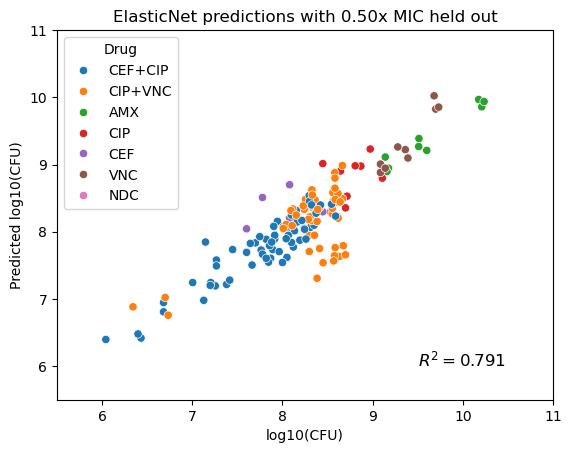

In [ ]:
# Scatterplot of predictions
eval_df12 = pd.DataFrame(y_test_12)

# Get predicted CFUs
eval_df12["Preds"] = en12.predict(X_test_12)

# Log 10 conversion
eval_df12[["CFU", "Preds"]] = eval_df12[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df12["Time"] = eval_df12.index
eval_df12["Time"] = eval_df12["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df12["Drug"] = eval_df12.index

# Drug names
eval_df12["Drug"] = eval_df12["Drug"].apply(drug_reader)

sns.scatterplot(eval_df12, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.50x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.7912:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### 0.75x MIC held out

In [ ]:
# Select indicies corresponding to if 1/4 MIC data
idx34_y = [i for i in range(X_all.shape[0]) if "34" in X_all.index[i]]
idx34_n = [i for i in range(X_all.shape[0]) if "34" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_34, y_train_34 = X_all.iloc[idx34_n], y_all.iloc[idx34_n]
X_test_34, y_test_34   = X_all.iloc[idx34_y], y_all.iloc[idx34_y]

# Scaler
scaler34 = StandardScaler()
scaler34.set_output(transform = "pandas")

# Fit scaler and transform data
scaler34.fit(X_train_34)
X_train_34 = scaler34.transform(X_train_34)
X_test_34  = scaler34.transform(X_test_34)

# Train EN model
en34 = linear_model.ElasticNetCV(cv = 5)

en34.fit(X_train_34, y_train_34)

print(eval_table(title = "0.75x MIC held out",
           model_list = [en34],
           name_list = ["ElasticNet"],
           data = [X_train_34, y_train_34, X_test_34, y_test_34]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                    0.75x MIC held out                   |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 1.2256 | 0.8716 |    0.9377   |   0.6059   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1ac7253dd10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

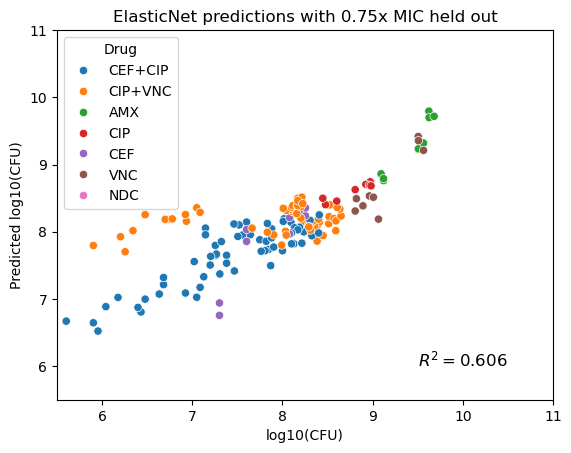

In [ ]:
# Scatterplot of predictions
eval_df34 = pd.DataFrame(y_test_34)

# Get predicted CFUs
eval_df34["Preds"] = en34.predict(X_test_34)

# Log 10 conversion
eval_df34[["CFU", "Preds"]] = eval_df34[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df34["Time"] = eval_df34.index
eval_df34["Time"] = eval_df34["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df34["Drug"] = eval_df34.index

# Drug names
eval_df34["Drug"] = eval_df34["Drug"].apply(drug_reader)

sns.scatterplot(eval_df34, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 0.75x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.6059:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### 1x MIC Held out

In [ ]:
# Select indicies corresponding to if 1/4 MIC data
idx1_y = [i for i in range(X_all.shape[0]) if X_all.index[i].startswith("1") and X_all.index[i][1].isalpha()]
idx1_n = [i for i in range(X_all.shape[0]) if not (X_all.index[i].startswith("1") and X_all.index[i][1].isalpha())]

# Subset data to 1/4 MIC or not
X_train_1, y_train_1 = X_all.iloc[idx1_n], y_all.iloc[idx1_n]
X_test_1, y_test_1   = X_all.iloc[idx1_y], y_all.iloc[idx1_y]

# Scaler
scaler1 = StandardScaler()
scaler1.set_output(transform = "pandas")

# Fit scaler and transform data
scaler1.fit(X_train_1)
X_train_1 = scaler1.transform(X_train_1)
X_test_1  = scaler1.transform(X_test_1)

# Train EN model
en1 = linear_model.ElasticNetCV(cv = 5)

en1.fit(X_train_1, y_train_1)

print(eval_table(title = "0.1x MIC held out",
           model_list = [en1],
           name_list = ["ElasticNet"],
           data = [X_train_1, y_train_1, X_test_1, y_test_1]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.387e-01, tolerance: 1.351e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.441e-01, tolerance: 1.351e-01
  model = cd_fast.enet_coordin

+-------------------------------------------------------+
|                   0.1x MIC held out                   |
+------------+------+--------+-------------+------------+
|   Model    | RMSE |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+------+--------+-------------+------------+
| ElasticNet | 1.67 | 1.3622 |    0.9571   |   -0.268   |
+------------+------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1ac711e2710>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

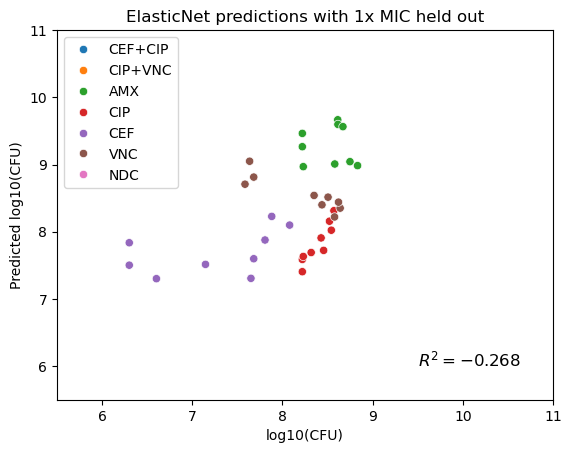

In [ ]:
# Scatterplot of predictions
eval_df1 = pd.DataFrame(y_test_1)

# Get predicted CFUs
eval_df1["Preds"] = en1.predict(X_test_1)

# Log 10 conversion
eval_df1[["CFU", "Preds"]] = eval_df1[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df1["Time"] = eval_df1.index
eval_df1["Time"] = eval_df1["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df1["Drug"] = eval_df1.index

# Drug names
eval_df1["Drug"] = eval_df1["Drug"].apply(drug_reader)

sns.scatterplot(eval_df1, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 1x MIC held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {-0.268:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.legend(loc = "upper left")
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### Held out 1hr

In [54]:
# Select indicies corresponding to if 1/4 MIC data
idx1hr_y = [i for i in range(X_all.shape[0]) if "1hr" in X_all.index[i]]
idx1hr_n = [i for i in range(X_all.shape[0]) if "1hr" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_1hr, y_train_1hr = X_all.iloc[idx1hr_n], y_all.iloc[idx1hr_n]
X_test_1hr, y_test_1hr   = X_all.iloc[idx1hr_y], y_all.iloc[idx1hr_y]

# Scaler
scaler1hr = StandardScaler()
scaler1hr.set_output(transform = "pandas")

# Fit scaler and transform data
scaler1hr.fit(X_train_1hr)
X_train_1hr = scaler1hr.transform(X_train_1hr)
X_test_1hr  = scaler1hr.transform(X_test_1hr)

# Train EN model
en1hr = linear_model.ElasticNetCV(cv = 5)

en1hr.fit(X_train_1hr, y_train_1hr)

print(eval_table(title = "1hr timepoint held out",
           model_list = [en1hr],
           name_list = ["ElasticNet"],
           data = [X_train_1hr, y_train_1hr, X_test_1hr, y_test_1hr]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+---------------------------------------------------------+
|                  1hr timepoint held out                 |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 1.1222 | 0.8849 |    0.9165   |  -0.2416   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1f681d93b10>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

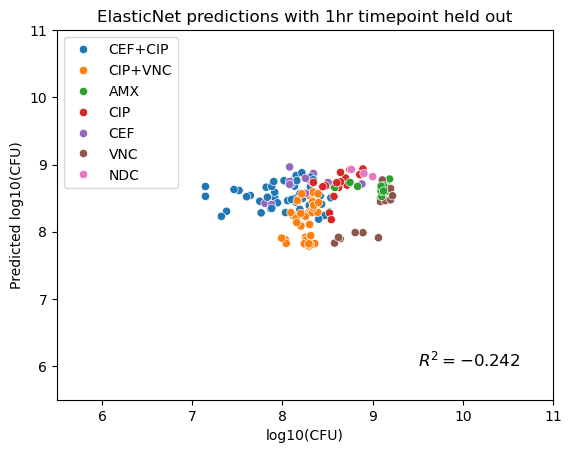

In [59]:
# Scatterplot of predictions
eval_df1hr = pd.DataFrame(y_test_1hr)

# Get predicted CFUs
eval_df1hr["Preds"] = en1hr.predict(X_test_1hr)

# Log 10 conversion
eval_df1hr[["CFU", "Preds"]] = eval_df1hr[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df1hr["Time"] = eval_df1hr.index
eval_df1hr["Time"] = eval_df1hr["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df1hr["Drug"] = eval_df1hr.index

# Drug names
eval_df1hr["Drug"] = eval_df1hr["Drug"].apply(drug_reader)

sns.scatterplot(eval_df1hr, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 1hr timepoint held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {-0.2416:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.legend(loc = "upper left")
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### Held out 2 hr

In [60]:
# Select indicies corresponding to if 1/4 MIC data
idx2hr_y = [i for i in range(X_all.shape[0]) if "2hr" in X_all.index[i]]
idx2hr_n = [i for i in range(X_all.shape[0]) if "2hr" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_2hr, y_train_2hr = X_all.iloc[idx2hr_n], y_all.iloc[idx2hr_n]
X_test_2hr, y_test_2hr   = X_all.iloc[idx2hr_y], y_all.iloc[idx2hr_y]

# Scaler
scaler2hr = StandardScaler()
scaler2hr.set_output(transform = "pandas")

# Fit scaler and transform data
scaler2hr.fit(X_train_2hr)
X_train_2hr = scaler2hr.transform(X_train_2hr)
X_test_2hr  = scaler2hr.transform(X_test_2hr)

# Train EN model
en2hr = linear_model.ElasticNetCV(cv = 5)

en2hr.fit(X_train_2hr, y_train_2hr)

print(eval_table(title = "2hr timepoint held out",
           model_list = [en2hr],
           name_list = ["ElasticNet"],
           data = [X_train_2hr, y_train_2hr, X_test_2hr, y_test_2hr]))


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.360e-01, tolerance: 9.507e-02
  model = cd_fast.enet_coordinate_descent(


+---------------------------------------------------------+
|                  2hr timepoint held out                 |
+------------+--------+--------+-------------+------------+
|   Model    |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+------------+--------+--------+-------------+------------+
| ElasticNet | 0.6291 | 0.4882 |    0.9185   |   0.8038   |
+------------+--------+--------+-------------+------------+


([<matplotlib.axis.YTick at 0x1f682354410>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

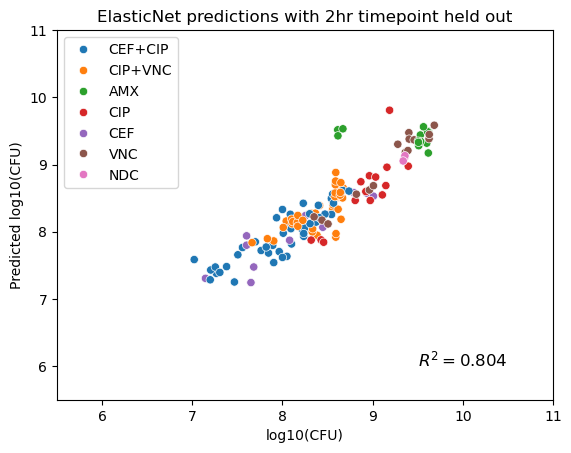

In [61]:
# Scatterplot of predictions
eval_df2hr = pd.DataFrame(y_test_2hr)

# Get predicted CFUs
eval_df2hr["Preds"] = en2hr.predict(X_test_2hr)

# Log 10 conversion
eval_df2hr[["CFU", "Preds"]] = eval_df2hr[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df2hr["Time"] = eval_df2hr.index
eval_df2hr["Time"] = eval_df2hr["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df2hr["Drug"] = eval_df2hr.index

# Drug names
eval_df2hr["Drug"] = eval_df2hr["Drug"].apply(drug_reader)

sns.scatterplot(eval_df2hr, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 2hr timepoint held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.8038:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.legend(loc = "upper left")
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))


### Held out 4 hr

In [62]:
# Select indicies corresponding to if 1/4 MIC data
idx4hr_y = [i for i in range(X_all.shape[0]) if "4hr" in X_all.index[i]]
idx4hr_n = [i for i in range(X_all.shape[0]) if "4hr" not in X_all.index[i]]

# Subset data to 1/4 MIC or not
X_train_4hr, y_train_4hr = X_all.iloc[idx4hr_n], y_all.iloc[idx4hr_n]
X_test_4hr, y_test_4hr   = X_all.iloc[idx4hr_y], y_all.iloc[idx4hr_y]

# Scaler
scaler4hr = StandardScaler()
scaler4hr.set_output(transform = "pandas")

# Fit scaler and transform data
scaler4hr.fit(X_train_4hr)
X_train_4hr = scaler4hr.transform(X_train_4hr)
X_test_4hr  = scaler4hr.transform(X_test_4hr)

# Train EN model
en4hr = linear_model.ElasticNetCV(cv = 5)

en4hr.fit(X_train_4hr, y_train_4hr)

print(eval_table(title = "4hr timepoint held out",
           model_list = [en4hr],
           name_list = ["ElasticNet"],
           data = [X_train_4hr, y_train_4hr, X_test_4hr, y_test_4hr]))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


+--------------------------------------------------------+
|                 4hr timepoint held out                 |
+------------+--------+-------+-------------+------------+
|   Model    |  RMSE  |  MAE  | R^2 (Train) | R^2 (Test) |
+------------+--------+-------+-------------+------------+
| ElasticNet | 1.3745 | 1.028 |    0.971    |   0.7511   |
+------------+--------+-------+-------------+------------+


([<matplotlib.axis.YTick at 0x1f6830c6ad0>,
 [Text(0, 6.0, '6'),
  Text(0, 7.0, '7'),
  Text(0, 8.0, '8'),
  Text(0, 9.0, '9'),
  Text(0, 10.0, '10'),
  Text(0, 11.0, '11')])

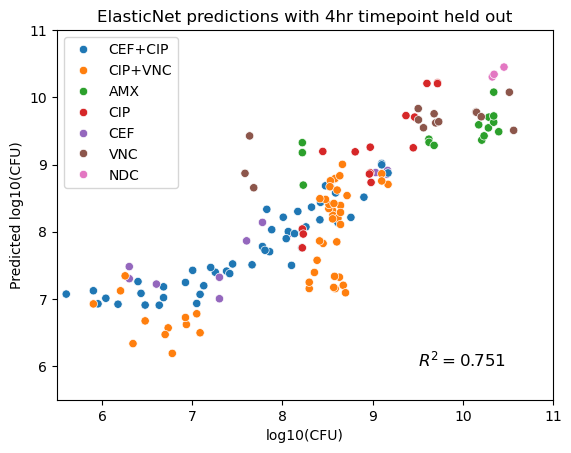

In [64]:
# Scatterplot of predictions
eval_df4hr = pd.DataFrame(y_test_4hr)

# Get predicted CFUs
eval_df4hr["Preds"] = en4hr.predict(X_test_4hr)

# Log 10 conversion
eval_df4hr[["CFU", "Preds"]] = eval_df4hr[["CFU", "Preds"]].apply(lambda x: x / np.log(10))

# Get time IDs
eval_df4hr["Time"] = eval_df4hr.index
eval_df4hr["Time"] = eval_df4hr["Time"].apply(lambda x: x[-5:-2])

# Get drug
eval_df4hr["Drug"] = eval_df4hr.index

# Drug names
eval_df4hr["Drug"] = eval_df4hr["Drug"].apply(drug_reader)

sns.scatterplot(eval_df4hr, x = "CFU", y = "Preds", hue = "Drug", hue_order = ordered_drugs)
plt.title("ElasticNet predictions with 4hr timepoint held out")
plt.ylabel("Predicted log10(CFU)")
plt.xlabel("log10(CFU)")
plt.text(9.5, 6, f'$R^2 = {0.751:.3f}$', fontsize=12)
plt.xlim(5.5, 11)
plt.ylim(5.5, 11)
plt.legend(loc = "upper left")
plt.xticks(np.arange(6,11.5))
plt.yticks(np.arange(6,11.5))
